In [1]:
# environment setup using python virtual environments and pip package manager
%pip install pandas seaborn matplotlib numpy Ipython kagglehub scikit-learn pyarrow


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Assignment 3  - CSI4142
Student names: Sameed Jafri (300253861), Jaime Bly (300231604)

work spilt:
- dataset 1: Jamie Bly
- dataset 2: Sameed Jafri



### Dataset 1
Description: Predicts house prices with a couple of binary features.

Dataset Name: Housing Prices Regression Dataset

Author: Compiled by Kaggle user Den_Kuznetz


Purpose: This is a real-world, non-synthetic dataset created to predict the price of real estate properties based on various features that influence the value of a property


Shape: The dataset contains exactly 500 rows and 12 columns.


Features and Descriptions 

ID: A unique identifier for each property.

Square_Feet: The area of the property in square meters.

Num_Bedrooms: The number of bedrooms in the property.

Num_Bathrooms: The number of bathrooms in the property.

Num_Floors: The number of floors in the property.

Year_Built: The year the property was built.

Has_Garden: Indicates whether the property has a garden (1 for yes, 0 for no).

Has_Pool: Indicates whether the property has a pool (1 for yes, 0 for no).

Garage_Size: The size of the garage in square meters.

Location_Score: A score from 0 to 10 indicating the quality of the neighborhood (higher scores indicate better neighborhoods).

Distance_to_Center: The distance from the property to the city center in kilometers.

Price: The target variable that represents the price of the property. This is the value we aim to predict.

Objective:
The goal of this task is to develop a regression model that predicts the Price of a real estate property using the other features as inputs. The model should be able to learn the relationship between these features and the price, providing an accurate prediction for unseen data.


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import sklearn.metrics
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold


# Set the path to the file you'd like to load
file_path = "real_estate_dataset.csv"

# Load the latest version
house_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "denkuznetz/housing-prices-regression",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", house_df.head())

/tmp/ipykernel_46493/1211763826.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  house_df = kagglehub.load_dataset(


First 5 records:    ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.061466           10.827392   
2           1         0           14        2.911442            6.904599   
3           0         0           17        2.070949            8.284019   
4           1         0           34        1.523278           14.648277   

           Price  
0  602134.816747  
1  591425.135386  
2  464478.696880  

In [3]:
#Validity Checks

# Checking uniqueness of ID
# Checker code to find uniqueness errors in the ID feature
# We use the duplicated() method. keep=False ensures we flag ALL instances of the duplicate, 
# not just the subsequent ones.
duplicate_mask = house_df.duplicated(subset=['ID'], keep=False)

# Extract the rows where the error was detected
detected_uniqueness_errors = house_df[duplicate_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_uniqueness_errors)} uniqueness errors.")
print("The automated check found multiple distinct rows sharing the exact same primary key (ID).")
print("\nExamples of the detected invalid data points (Notice the identical IDs):")

display(detected_uniqueness_errors[['ID']].head(3))



# For Square_Feet
# Checker code to find data type errors
# Attempting to convert the Square_Feet column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Square_Feet'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where an integer for minimum nights was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Square_Feet']].head(3))



# Num_Bedrooms
# Checker code to find range errors
# Filter the dataframe to find any rows where number of bedrooms is less than or equal to 0.
range_error_mask = house_df['Num_Bedrooms'] <= 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the number of rooms was logically impossible (less than or equal to zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Num_Bedrooms']].head(3))


# Num_Bathrooms
# Checker code to find range errors
# Filter the dataframe to find any rows where number of bathrooms is less than or equal to 0.
range_error_mask = house_df['Num_Bathrooms'] <= 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the number of bathrooms was logically impossible (less than or equal to zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Num_Bathrooms']].head(3))


# Num_Bedrooms
# Checker code to find range errors
# Filter the dataframe to find any rows where number of bedrooms is less than or equal to 0.
range_error_mask = house_df['Num_Floors'] <= 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the number of floors was logically impossible (less than or equal to zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Num_Bedrooms']].head(3))



# Year-Built
# Checker code to find data type errors
# Attempting to convert the column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Year_Built'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]
# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where an integer for minimum nights was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Year_Built']].head(3))

# Checker code to find range errors
# Filter the dataframe to find any rows where 'Year_Built' is greater than (assumed) year collected 
range_error_mask = house_df['Year_Built'] > 2022

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the nightly price was logically impossible (less than zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Year_Built']].head(3))



# Has_Pool
# Checker code to find look-up errors
# Define the accepted dictionary/look-up list
valid_has_pool_answers = [0, 1]

# Flag rows where the Has_Pool is NOT IN the valid list
lookup_error_mask = ~house_df['Has_Pool'].isin(valid_has_pool_answers)

# Extract the rows where the error was detected
detected_lookup_errors = house_df[lookup_error_mask]
# Report of findings
print(f"The validity checker successfully detected {len(detected_lookup_errors)} look-up errors.")
print("The automated check caught categorical values (3) that do not belong to the accepted answers for Has_Pool.")
print("\nExamples of the detected invalid data points:")

display(detected_lookup_errors[['ID', 'Has_Pool']].head(3))



# For Garage_Size
# Checker code to find data type errors
# Attempting to convert the Garage_Size column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Garage_Size'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center  was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Garage_Size']].head(3))

# For Distance_to_Center
# Checker code to find data type errors
# Attempting to convert the Distance_to_Center column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Distance_to_Center'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Garage_Size']].head(3))



# Location_Score
# Checker code to find range errors
# Filter the dataframe to find any rows where 'price' is less than 0
range_error_mask = house_df['Location_Score'] >= 10

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the Location_score is greater than the given range (greater than 10).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Location_Score']].head(3))
# Checker code to find range errors
# Filter the dataframe to find any rows where 'price' is less than 0
range_error_mask = house_df['Location_Score'] < 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the Location_score is less than the given range (less than 0).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Location_Score']].head(3))



#Price
# For Garage_Size
# Checker code to find data type errors
# Attempting to convert the Price column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Price'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center  was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Price']].head(3))

The validity checker successfully detected 0 uniqueness errors.
The automated check found multiple distinct rows sharing the exact same primary key (ID).

Examples of the detected invalid data points (Notice the identical IDs):


,ID


The validity checker successfully detected 0 data type errors.
The automated check identified rows containing non-numeric values ('invalid_string') where an integer for minimum nights was expected.

Examples of the detected invalid data points:


,ID,Square_Feet


The validity checker successfully detected 0 range errors.
The automated check identified rows where the number of rooms was logically impossible (less than or equal to zero).

Examples of the detected invalid data points:


...

,ID,Location_Score


The validity checker successfully detected 0 range errors.
The automated check identified rows where the Location_score is less than the given range (less than 0).

Examples of the detected invalid data points:


,ID,Location_Score


The validity checker successfully detected 0 data type errors.
The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center  was expected.

Examples of the detected invalid data points:


,ID,Price


### Categorical feature encoding

Not necessary for this dataset, as it is all numerical features.

### Local Outlier 

As shown below, you can see how n_neighbors effects the number of outliers. Most of the outliers, except for 5, show that the outliers are on the ends of the price range. 
As such I will N=15 for this dataset, as it shows a good middle ground of eliminating potential outliers, while not removing potential useful data. For this data, I will remove them, as they essentially represent the edge cases, which absolutes that for the average example, they will have minimal effect. 

Total Number of Outliers at n_neighbors=5: 31


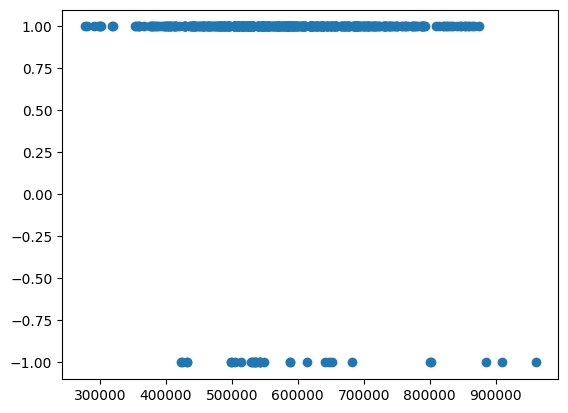

Total Number of Outliers at n_neighbors=10: 2


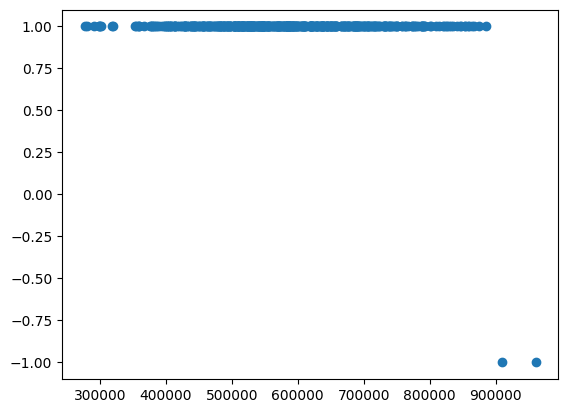

Total Number of Outliers at n_neighbors=20: 12


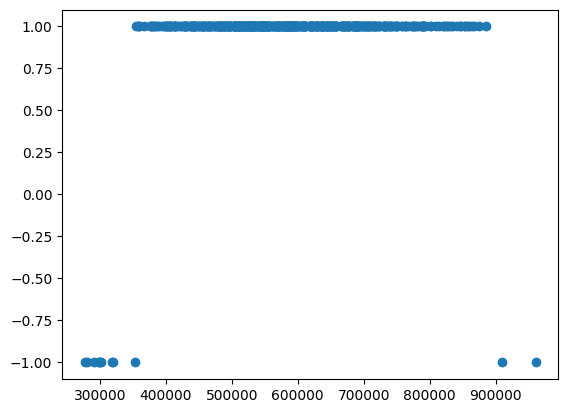

Total Number of Outliers at n_neighbors=30: 14


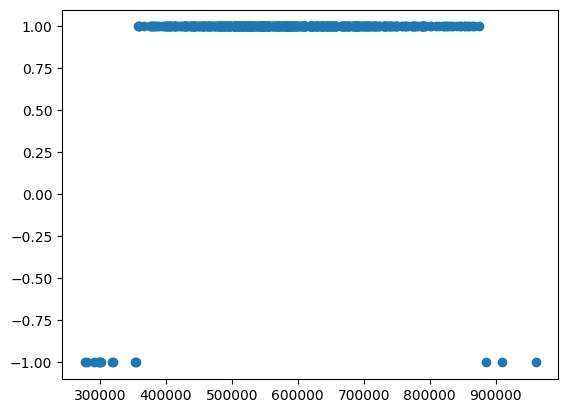

Total Number of Outliers at n_neighbors=15: 11


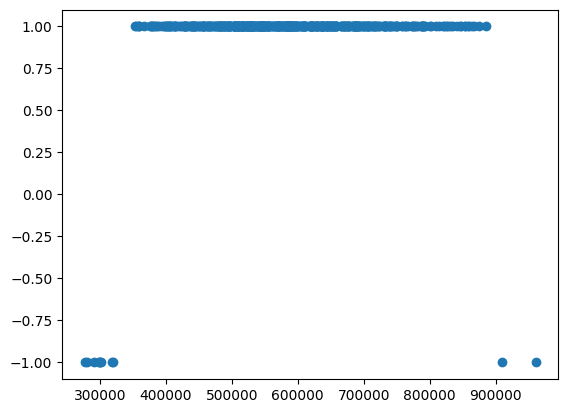

In [4]:
house_lof_5= LocalOutlierFactor(n_neighbors=5, contamination='auto')
house_lof_prediction = house_lof_5.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=5:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof_5= LocalOutlierFactor(n_neighbors=10, contamination='auto')
house_lof_prediction = house_lof_5.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=10:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof= LocalOutlierFactor(n_neighbors=20, contamination='auto')
house_lof_prediction = house_lof.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=20:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof= LocalOutlierFactor(n_neighbors=30, contamination='auto')
house_lof_prediction = house_lof.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=30:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof= LocalOutlierFactor(n_neighbors=15, contamination='auto')
house_lof_prediction = house_lof.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=15:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()



In [5]:
#Removing outliers

outlier_house_df = house_df.copy()
outlier_house_df["Outlier"] = (house_lof_prediction)
cleaned_house_df =  outlier_house_df[outlier_house_df['Outlier'] == 1]
outlier_house_df =  outlier_house_df[outlier_house_df['Outlier'] == -1]
print(outlier_house_df)
cleaned_house_df = cleaned_house_df.drop('Outlier', axis=1)
print(cleaned_house_df.head(3))


      ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
52    53   284.874735             5              2           2        2012   
90    91    79.898561             1              1           2        1920   
102  103   128.588995             1              2           3        1901   
148  149    62.869688             1              1           2        1983   
150  151   277.066471             5              2           3        2019   
171  172    54.146957             2              1           1        1935   
224  225   116.300592             1              2           1        1920   
294  295    81.765128             1              2           1        1910   
356  357    56.627828             2              2           1        1938   
409  410    72.821669             1              1           2        1928   
434  435    71.026702             1              1           1        1931   

     Has_Garden  Has_Pool  Garage_Size  Location_Score  Distanc

### Feature Engineering

In [6]:
cleaned_house_df["Agg_total_features"] = cleaned_house_df['Num_Bedrooms'] + cleaned_house_df['Num_Bathrooms'] + 2 * cleaned_house_df['Has_Garden'] + 2 * cleaned_house_df['Has_Pool']
print(cleaned_house_df['Agg_total_features'].head(5))

cleaned_house_df["Agg_features_Sq"] =  cleaned_house_df['Agg_total_features'] /cleaned_house_df['Square_Feet'] 
print(cleaned_house_df['Agg_features_Sq'].head(5))

print(cleaned_house_df.head(5))


0    8
1    5
2    6
3    7
4    9
Name: Agg_total_features, dtype: int64
0    0.055697
1    0.017381
2    0.025751
3    0.035059
4    0.101118
Name: Agg_features_Sq, dtype: float64
   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.061466           10.827392   
2           1         0           14        2.911442            6.904599   
3           0         0           17        2.070949           

### Splitting Data

In [7]:
base_price = house_df['Price']
base_features = house_df.drop('Price', axis=1)
base_x_train_reduced, base_x_test, base_y_train_reduced, base_y_test = train_test_split(base_features, base_price, test_size=0.2, random_state=42)
base_x_train, base_x_val, base_y_train, base_y_val = train_test_split(base_x_train_reduced, base_y_train_reduced, test_size=0.25, random_state=42)

base_model = LinearRegression().fit(base_x_train, base_y_train)

base_scores_r2 = cross_val_score(base_model, base_x_val, base_y_val, cv=4, scoring='r2')
print("Base Model Cross Validation Results (r2):",base_scores_r2)



agg_price = house_df['Price']
agg_house_df = house_df.drop('Price', axis=1)
agg_house_df["Agg_total_features"] = agg_house_df['Num_Bedrooms'] + agg_house_df['Num_Bathrooms'] + 2 * agg_house_df['Has_Garden'] + 2 * agg_house_df['Has_Pool']
agg_house_df["Agg_features_Sq"] = agg_house_df['Agg_total_features'] / agg_house_df['Square_Feet']

agg_x_train_reduced, agg_x_test, agg_y_train_reduced, agg_y_test = train_test_split(agg_house_df, agg_price, test_size=0.2, random_state=42)
agg_x_train, agg_x_val, agg_y_train, agg_y_val = train_test_split(agg_x_train_reduced, agg_y_train_reduced, test_size=0.25, random_state=42)

agg_model = LinearRegression().fit(agg_x_train, agg_y_train)

agg_scores_r2 = cross_val_score(agg_model, agg_x_val, agg_y_val, cv=4, scoring='r2')
print("Aggregated Features Model Cross Validation Results (r2):", agg_scores_r2)




no_out_price = cleaned_house_df['Price']
no_out_house_df = cleaned_house_df.drop(['Price', 'Agg_total_features', 'Agg_features_Sq'], axis=1)

no_out_x_train_reduced, no_out_x_test, no_out_y_train_reduced, no_out_y_test = train_test_split(no_out_house_df, no_out_price, test_size=0.2, random_state=42)
no_out_x_train, no_out_x_val, no_out_y_train, no_out_y_val = train_test_split(no_out_x_train_reduced, no_out_y_train_reduced, test_size=0.25, random_state=42)

no_out_model = LinearRegression().fit(no_out_x_train, no_out_y_train)

no_out_scores_r2 = cross_val_score(no_out_model, no_out_x_val, no_out_y_val, cv=4, scoring='r2')
print("No Outliers Model Cross Validation Results (r2):", no_out_scores_r2)



#print(cleaned_house_df)
price = cleaned_house_df['Price']
features = cleaned_house_df.drop('Price', axis=1)
x_train_reduced, x_test, y_train_reduced, y_test = train_test_split(features, price, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_reduced, y_train_reduced, test_size=0.25, random_state=42)

model = LinearRegression().fit(x_train, y_train)
scores_r2 = cross_val_score(model, x_val, y_val, cv=4, scoring='r2')
print("Final Model Cross Validation Results (r2):", scores_r2)

best_model = LinearRegression().fit(x_train_reduced, y_train_reduced)
best_model_scores_r2 = cross_val_score(best_model, x_test, y_test, cv=4, scoring='r2')
print("Best Model Cross Validation Results (r2):", best_model_scores_r2)






Base Model Cross Validation Results (r2): [0.94700923 0.96101754 0.96910904 0.96857918]
Aggregated Features Model Cross Validation Results (r2): [0.94890357 0.95661099 0.97099633 0.96989706]
No Outliers Model Cross Validation Results (r2): [0.9538778  0.97307909 0.97422533 0.96256515]
Final Model Cross Validation Results (r2): [0.94792691 0.97306824 0.97347472 0.96230761]
Best Model Cross Validation Results (r2): [0.95560293 0.96557988 0.98036258 0.96952456]


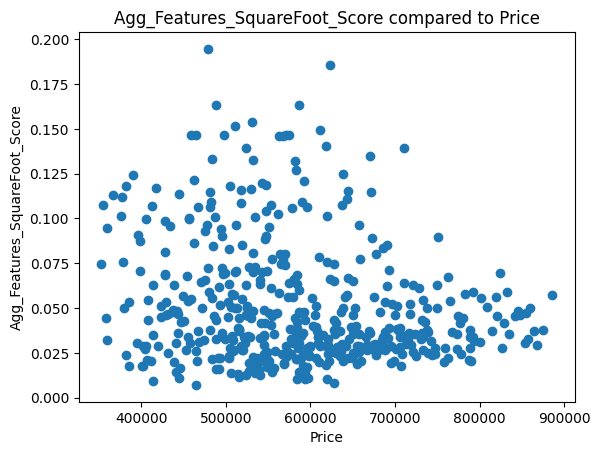

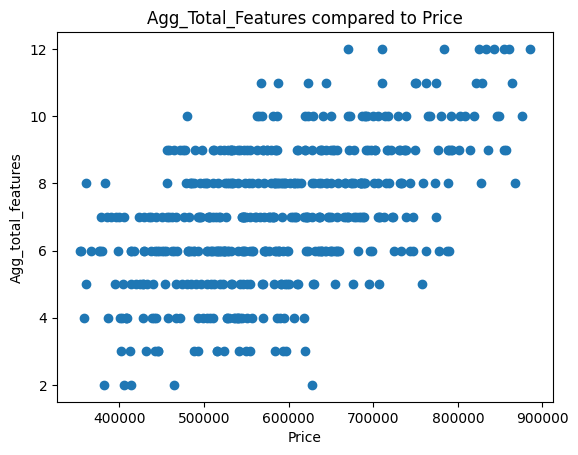

In [9]:
cleaned_house_df["Agg_Features_SquareFoot_Score"] =  cleaned_house_df['Agg_total_features'] /cleaned_house_df['Square_Feet'] 
plt.scatter(cleaned_house_df['Price'], cleaned_house_df['Agg_Features_SquareFoot_Score'])
plt.title("Agg_Features_SquareFoot_Score compared to Price")
plt.xlabel("Price")
plt.ylabel("Agg_Features_SquareFoot_Score")
plt.show()

plt.scatter(cleaned_house_df['Price'], cleaned_house_df['Agg_total_features'])
plt.title("Agg_Total_Features compared to Price")
plt.xlabel("Price")
plt.ylabel("Agg_total_features")
plt.show()

### Result Analysis

Looking at the above results, adding feature aggregation had a slight positive impacted the overall performance of the model. I attempted a few different combinations and aggregations, including aggregations of Location score and sq foot, locaton score and distance from center, and none seemed to have a significant positive impact. This tells me either that there is not a strong correlation between the features themselves and the final price (other than features and sq feet), or that my understanding of the domain is limited and I require a domain expert or further domain knowledge to find more complex aggregation that will yield better results 

The outliers removed showed the overall better, and overall was the most successful of the two method models. It showed clear improved over the base, and performed superior to all others models, except for the combination, which it's performance was quite comparable to. 

The final combination of the two results yield better results than the base model, but performed similarly to the outlier removed model.

The final testing done with the hidden test data performed similarly to the validation runs. This tells me that the model is quite stable on this dataset, as there is no major changes to the difference between the R2 scores of the models. Overall these models performed well on the data, and fits the dataset very well , as its  lowest R2 results was over 94%, which is very high.  


### Dataset 2 

* **Description:** EMBER (Vectorized Subset)
* **Dataset Name:** EMBER 2017 v2 (Kaggle Vectorized Subset)
* **Author:** Hyrum S. Anderson and Phil Roth (Endgame)
* **Purpose:** This dataset was specifically created to train machine learning models for the static analysis of Windows Portable Executable (PE) files. It is not synthetic; it is derived from real-world benign and malicious binaries.
* **Shape:** 50,000 rows and 2,382 columns.

**Features and Descriptions**
Instead of raw strings, the raw executables have been pre-processed and flattened into a 2,381-dimensional numerical array (`F1` through `F2381`) to allow for machine learning ingestion. According to the dataset authors, these dimensions conceptually map to 8 distinct structural feature categories extracted from the files:

1. **Byte Histogram (256 dimensions - `F1` to `F256`):** Normalized counts of each byte value (0-255) across the entire file (Numerical / Float).
2. **Byte-Entropy Histogram (256 dimensions - `F257` to `F512`):** A 2D histogram jointly modeling byte values and local entropy, used to detect packed/encrypted regions (Numerical / Float).
3. **String Extraction (104 dimensions):** Statistics on printable strings, including lengths, character distributions, and counts of URLs/registry keys (Numerical / Float).
4. **General File Information (10 dimensions):** High-level scalar metadata, such as apparent size, virtual size, and binary signature presence (Numerical / Float).
5. **Header Information (62 dimensions):** Characteristics extracted from the DOS, COFF, and Optional PE headers (Numerical / Float).
6. **Section Information (255 dimensions):** Properties of up to 50 PE sections, including section sizes and entropy distributions (Numerical / Float).
7. **Imported Functions (1,280 dimensions):** Hashed vector representing the external DLLs and specific functions the program imports (Numerical / Float).
8. **Exported Functions (128 dimensions):** Hashed vector representing the functions the executable exports (Numerical / Float).
* **`Label`**: The target variable. `1.0` indicates malicious, `0.0` indicates benign (Categorical).

In [1]:
# Download the EMBER 2017 v2 dataset from Kaggle using kagglehub,
# then list all available files in the downloaded folder.
import kagglehub
import os

# Download the dataset (this returns a folder path)
dataset_folder = kagglehub.dataset_download("dhoogla/ember-2017-v2-features")

print(f"Folder downloaded to: {dataset_folder}")

# List all the files inside that folder
files_in_folder = os.listdir(dataset_folder)
print("Files available to load:")
for file in files_in_folder:
    print(f" - {file}")

Folder downloaded to: /home/m33d/.cache/kagglehub/datasets/dhoogla/ember-2017-v2-features/versions/2
Files available to load:
 - train_ember_2017_v2_features.parquet
 - test_ember_2017_v2_features.parquet


In [2]:
# Load the train and test parquet files from the downloaded EMBER dataset.
# The raw file is sorted by label, so taking the first N rows only includes
# one class. We read in small batches and collect rows from both classes
# to avoid loading the full file into memory (which crashes the kernel).
import pandas as pd
import pyarrow.parquet as pq
import os

dataset_folder = "/home/m33d/.cache/kagglehub/datasets/dhoogla/ember-2017-v2-features/versions/2"

def load_balanced_sample(file_path, n_samples, batch_size=10000):
    """Load a balanced sample from a parquet file using small batches.
    Filters out unlabeled rows (Label == -1.0) and collects equal numbers
    of benign (0.0) and malicious (1.0) samples."""
    pf = pq.ParquetFile(file_path)
    benign_chunks = []
    malicious_chunks = []
    target_per_class = n_samples // 2

    for batch in pf.iter_batches(batch_size=batch_size):
        df_batch = batch.to_pandas()
        
        if len(benign_chunks) == 0 or benign_chunks[-1].shape[0] < target_per_class:
            benign = df_batch[df_batch['Label'] == 0.0]
            benign_chunks.append(benign)
        
        if len(malicious_chunks) == 0 or malicious_chunks[-1].shape[0] < target_per_class:
            malicious = df_batch[df_batch['Label'] == 1.0]
            malicious_chunks.append(malicious)
        
        # Check if we have enough of both classes
        total_benign = sum(c.shape[0] for c in benign_chunks)
        total_malicious = sum(c.shape[0] for c in malicious_chunks)
        if total_benign >= target_per_class and total_malicious >= target_per_class:
            break

    df_benign = pd.concat(benign_chunks).head(target_per_class)
    df_malicious = pd.concat(malicious_chunks).head(target_per_class)
    result = pd.concat([df_benign, df_malicious]).sample(frac=1, random_state=42).reset_index(drop=True)
    return result

# --- Training set (50,000 rows: 25,000 benign + 25,000 malicious) ---
train_file_path = os.path.join(dataset_folder, "train_ember_2017_v2_features.parquet")
print("Loading training parquet file...")
df_train_full = load_balanced_sample(train_file_path, n_samples=50000)

# --- Test set (10,000 rows: 5,000 benign + 5,000 malicious) ---
test_file_path = os.path.join(dataset_folder, "test_ember_2017_v2_features.parquet")
print("Loading test parquet file...")
df_test = load_balanced_sample(test_file_path, n_samples=10000)

print(f"Training data shape: {df_train_full.shape}")
print(f"Test data shape:     {df_test.shape}")
print(f"\nTraining label distribution:\n{df_train_full['Label'].value_counts()}")
print(f"\nTest label distribution:\n{df_test['Label'].value_counts()}")

Loading training parquet file...
Loading test parquet file...
Training data shape: (50000, 2382)
Test data shape:     (10000, 2382)

Training label distribution:
Label
1.0    25000
0.0    25000
Name: count, dtype: int64

Test label distribution:
Label
1.0    5000
0.0    5000
Name: count, dtype: int64


In [3]:
# Quick sanity check: display the first 5 rows of the training data
# to verify the data loaded correctly and inspect feature structure.
print("First 5 rows of the training dataset:")
print(df_train_full.head())

First 5 rows of the training dataset:
         F1        F2        F3        F4        F5        F6        F7  \
0  0.018316  0.004374  0.003766  0.004476  0.004243  0.004140  0.003785   
1  0.192512  0.023929  0.007660  0.006150  0.009358  0.003461  0.002129   
2  0.486062  0.006137  0.004039  0.001642  0.003296  0.000588  0.001332   
3  0.495455  0.017087  0.000418  0.000418  0.002530  0.000209  0.000233   
4  0.144030  0.010990  0.003441  0.004881  0.008073  0.002277  0.002330   

         F8        F9       F10  ...  F2373  F2374  F2375  F2376     F2377  \
0  0.003841  0.003822  0.004187  ...    0.0    0.0    0.0   48.0  229596.0   
1  0.001120  0.005331  0.002990  ...    0.0    0.0    0.0  584.0  155648.0   
2  0.000899  0.004195  0.000655  ...    0.0   32.0  616.0  708.0    4096.0   
3  0.000307  0.000369  0.000319  ...    0.0    0.0    0.0    0.0       0.0   
4  0.002621  0.007946  0.002878  ...    0.0    0.0    0.0    0.0       0.0   

   F2378  F2379  F2380  F2381  Label  
0  

### Train/Validation/Test Split

We split the data immediately after loading, before any cleaning or feature engineering.
- The **test set** comes directly from the pre-split test parquet file.
- The **training parquet** is split into a reduced training set (85%) and a validation set (15%) using stratified sampling to preserve class distribution.

All subsequent cleaning, imputation, and feature engineering will be performed on the split sets to prevent data leakage from validation into training.

In [4]:
# ============================================================
# Split the data into train, validation, and test sets
# ============================================================
# Split is done BEFORE any cleaning or feature engineering to prevent
# data leakage. The test set uses the pre-split test parquet file.
from sklearn.model_selection import train_test_split

# Separate features and target from the training data
X_train_full = df_train_full.drop(columns=['Label'])
y_train_full = df_train_full['Label']

# Split training data into train and validation (~15% for validation)
X_train_reduced, X_val, y_train_reduced, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# Use the pre-split test parquet as the test set
X_test = df_test.drop(columns=['Label'])
y_test = df_test['Label']

print(f"Training Set Shape:   {X_train_reduced.shape}")
print(f"Validation Set Shape: {X_val.shape}")
print(f"Test Set Shape:       {X_test.shape}")

Training Set Shape:   (42500, 2381)
Validation Set Shape: (7500, 2381)
Test Set Shape:       (10000, 2381)


### 1. Data Cleaning: Validity Checks and Imputation
Drawing upon the data preparation techniques developed in Assignment 2, we must ensure the integrity of the 2,381 features before passing them to the Decision Tree. We run 8 validity checks on the raw training data (`df_train_full`) before splitting into train/validation sets.

**Validity Checks:**
1. **Data Type Error:** Enforce strict numerical types (float64/int64) across all feature columns and the Label.
2. **Range Error:** Since feature hashing was used during EMBER's vectorization, negative values are valid (hash collisions are resolved with alternating +1/-1 signs). Instead, we check for non-finite values (Inf/-Inf) indicating corrupted or overflowed features.
3. **Format Error:** Dormant — applies to string columns (e.g., sha256 hex pattern), but the vectorized dataset contains only floats.
4. **Consistency Error:** The Byte Histogram (F1-F256) represents a normalized probability distribution. We verify each row's sum falls within [0.99, 1.01] to account for floating-point rounding.
5. **Uniqueness Error:** Flag perfectly duplicated rows — two identical 2,381-dimensional vectors among 50,000 unique executables is highly suspicious.
6. **Presence Error:** Standard NaN/Null scan across all columns to catch parsing failures from the Endgame feature extraction.
7. **Length Error:** Verify the dataset has the expected 2,382 columns (2,381 features + 1 Label) to ensure no truncation during download.
8. **Look-up Error:** The Label must strictly be in {0.0, 1.0} (benign or malicious). Any other value is flagged for removal or coercion.

**Imputation:**
After standardizing the validity of the data, we will apply median imputation to handle any naturally occurring or coerced `NaN` values, ensuring the distributions of our structural PE features are not heavily skewed by extreme default values.

In [5]:
# ============================================================
# Validity Checks for Dataset 2 (EMBER)
# ============================================================
# All checks are performed on X_train_reduced only (post-split) to
# prevent data leakage from the validation or test sets.
import numpy as np

# --- 1. Data Type Error ---
# Every feature column must be a numerical type (float64 or int64).
# We scan all columns to ensure no strings, objects, or corrupted
# byte characters survived the Kaggle vectorization process.
print("=== 1. Data Type Error ===")
non_numeric_cols = X_train_reduced.select_dtypes(exclude=['number']).columns.tolist()
if len(non_numeric_cols) > 0:
    print(f"FOUND {len(non_numeric_cols)} non-numeric columns: {non_numeric_cols}")
else:
    print(f"All {len(X_train_reduced.columns)} columns are numeric. No data type errors detected.")


# --- 2. Range Error ---
# Feature hashing was used during EMBER's vectorization, which maps features into
# a fixed-size vector using a hash function. Hash collisions are resolved by
# alternating signs (+1/-1), so negative values are expected and valid across
# all feature columns. Therefore, we cannot flag negatives as range errors.
# Instead, we check for non-finite values (infinity or -infinity) which would
# indicate a corrupted or overflowed feature value.
print("\n=== 2. Range Error ===")
all_feature_cols = [f"F{i}" for i in range(1, 2382)]
inf_errors = np.isinf(X_train_reduced[all_feature_cols]).sum().sum()
print(f"Non-finite (Inf/-Inf) values in F1-F2381: {inf_errors} range errors detected.")


# --- 3. Format Error ---
# Format errors typically apply to string columns (e.g., regex matching).
# Since this dataset is composed entirely of floats with no sha256 hash column
# present after vectorization, this checker is dormant.
print("\n=== 3. Format Error ===")
if 'sha256' in X_train_reduced.columns:
    import re
    sha256_pattern = re.compile(r'^[a-fA-F0-9]{64}$')
    invalid_sha = X_train_reduced['sha256'].apply(lambda x: not bool(sha256_pattern.match(str(x))))
    format_errors = invalid_sha.sum()
    print(f"sha256 column found. {format_errors} format errors detected (not matching 64-char hex pattern).")
else:
    print("No sha256 column present in the vectorized dataset. Format check is dormant.")


# --- 4. Consistency Error ---
# The Byte Histogram (F1-F256) represents a normalized probability distribution
# of byte values. The sum of these 256 features should equal exactly 1.0 for
# each row. We allow a small floating-point tolerance (0.99 to 1.01).
print("\n=== 4. Consistency Error ===")
byte_histogram_cols = [f"F{i}" for i in range(1, 257)]
histogram_sums = X_train_reduced[byte_histogram_cols].sum(axis=1)
consistency_mask = (histogram_sums < 0.99) | (histogram_sums > 1.01)
consistency_errors = consistency_mask.sum()
print(f"Rows where sum(F1:F256) falls outside [0.99, 1.01]: {consistency_errors} consistency errors detected.")
if consistency_errors > 0:
    print(f"  Example sums from flagged rows: {histogram_sums[consistency_mask].head(3).values}")


# --- 5. Uniqueness Error ---
# In a dataset of unique executables, having two completely identical
# 2,381-dimensional feature vectors is highly suspicious and likely represents
# a duplicate entry rather than a coincidental match.
print("\n=== 5. Uniqueness Error ===")
duplicate_mask = X_train_reduced.duplicated(keep=False)
num_duplicates = duplicate_mask.sum()
print(f"Perfectly duplicated rows: {num_duplicates} uniqueness errors detected.")
if num_duplicates > 0:
    print(f"  Number of unique duplicate groups: {X_train_reduced[duplicate_mask].drop_duplicates().shape[0]}")


# --- 6. Presence Error ---
# Standard check for NaN, Null, or empty values across all columns.
# Missing floats in any F column could result from parsing failures during
# the Endgame feature extraction process.
print("\n=== 6. Presence Error ===")
null_counts = X_train_reduced.isnull().sum()
total_nulls = null_counts.sum()
print(f"Total missing (NaN/Null) values across all columns: {total_nulls} presence errors detected.")
if total_nulls > 0:
    cols_with_nulls = null_counts[null_counts > 0]
    print(f"  Columns with missing values:\n{cols_with_nulls}")


# --- 7. Length Error ---
# Length checks are typically for string columns. Since we are working with
# floats only, we verify that no row was truncated to fewer than the expected
# number of columns (2,381 features) during file download.
print("\n=== 7. Length Error ===")
expected_cols = 2381
actual_cols = X_train_reduced.shape[1]
if actual_cols != expected_cols:
    print(f"LENGTH ERROR: Expected {expected_cols} columns but found {actual_cols}.")
else:
    print(f"All rows have the expected {expected_cols} columns. No length errors detected.")


# --- 8. Look-up Error (Set Membership) ---
# The target Label must strictly belong to the set {0.0, 1.0}, where 0.0 is
# benign and 1.0 is malicious. Any other value (e.g., 0.5, -1.0, 2.0) is a
# look-up error and must be removed or coerced.
print("\n=== 8. Look-up Error (Set Membership) ===")
valid_labels = {0.0, 1.0}
invalid_label_mask = ~y_train_reduced.isin(valid_labels)
lookup_errors = invalid_label_mask.sum()
print(f"Rows with Label not in {{0.0, 1.0}}: {lookup_errors} look-up errors detected.")
if lookup_errors > 0:
    invalid_values = y_train_reduced[invalid_label_mask].unique()
    print(f"  Invalid label values found: {invalid_values}")

=== 1. Data Type Error ===
All 2381 columns are numeric. No data type errors detected.

=== 2. Range Error ===
Non-finite (Inf/-Inf) values in F1-F2381: 0 range errors detected.

=== 3. Format Error ===
No sha256 column present in the vectorized dataset. Format check is dormant.

=== 4. Consistency Error ===
Rows where sum(F1:F256) falls outside [0.99, 1.01]: 0 consistency errors detected.

=== 5. Uniqueness Error ===
Perfectly duplicated rows: 0 uniqueness errors detected.

=== 6. Presence Error ===
Total missing (NaN/Null) values across all columns: 0 presence errors detected.

=== 7. Length Error ===
All rows have the expected 2381 columns. No length errors detected.

=== 8. Look-up Error (Set Membership) ===
Rows with Label not in {0.0, 1.0}: 0 look-up errors detected.


In [6]:
# ============================================================
# Imputation: Median imputation for any NaN values
# ============================================================
# The median is computed ONLY from X_train_reduced to prevent data leakage.
# The same fitted imputer is then applied to both X_train_reduced and X_val
# so that the validation set uses training statistics, not its own.
from sklearn.impute import SimpleImputer

# Count NaN values before imputation
nan_train = X_train_reduced.isnull().sum().sum()
nan_val = X_val.isnull().sum().sum()
print(f"NaN values in training set:   {nan_train}")
print(f"NaN values in validation set: {nan_val}")

if nan_train > 0 or nan_val > 0:
    # Fit imputer on training data only, then transform both sets
    imputer = SimpleImputer(strategy='median')
    X_train_reduced = pd.DataFrame(
        imputer.fit_transform(X_train_reduced),
        columns=X_train_reduced.columns,
        index=X_train_reduced.index
    )
    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    nan_after_train = X_train_reduced.isnull().sum().sum()
    nan_after_val = X_val.isnull().sum().sum()
    print(f"\nAfter imputation:")
    print(f"  Training set NaN:   {nan_after_train}")
    print(f"  Validation set NaN: {nan_after_val}")
    print("Median imputation applied successfully (fitted on training data only).")
else:
    print("No missing values detected. Imputation is not required.")

NaN values in training set:   0
NaN values in validation set: 0
No missing values detected. Imputation is not required.


### 2. Outlier Detection with Local Outlier Factor (LOF)

Since LOF is computationally expensive on high-dimensional data (2,381 features), we first use EDA to identify which features exhibit potential outliers. We examine the distribution of a representative subset of features using box plots and summary statistics to find columns with extreme values worth investigating.

Once candidate features are identified, we apply LOF on those features to detect local density-based outliers. Detected outliers will be treated as missing values and imputed using median imputation, preserving the dataset size for training.

Top 10 features by IQR-based outlier percentage:
  F273: 24.03%
  F687: 23.61%
  F2362: 23.03%
  F299: 22.57%
  F799: 22.43%
  F302: 22.41%
  F298: 21.47%
  F301: 21.32%
  F300: 21.31%
  F699: 21.15%


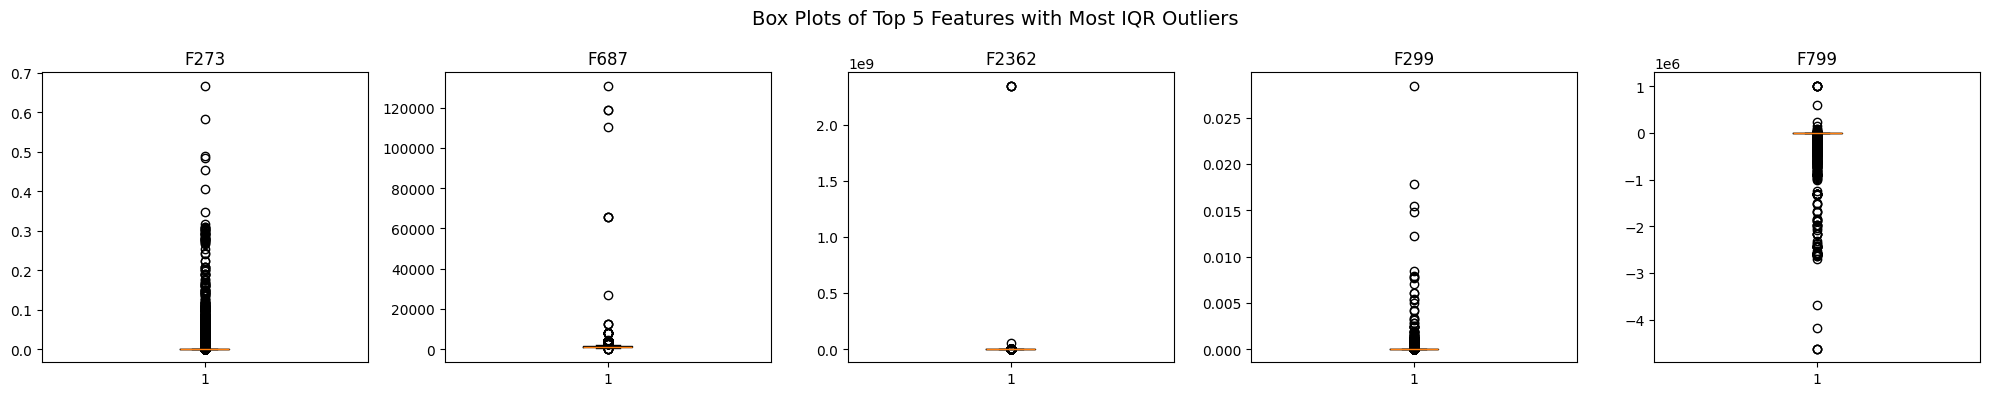

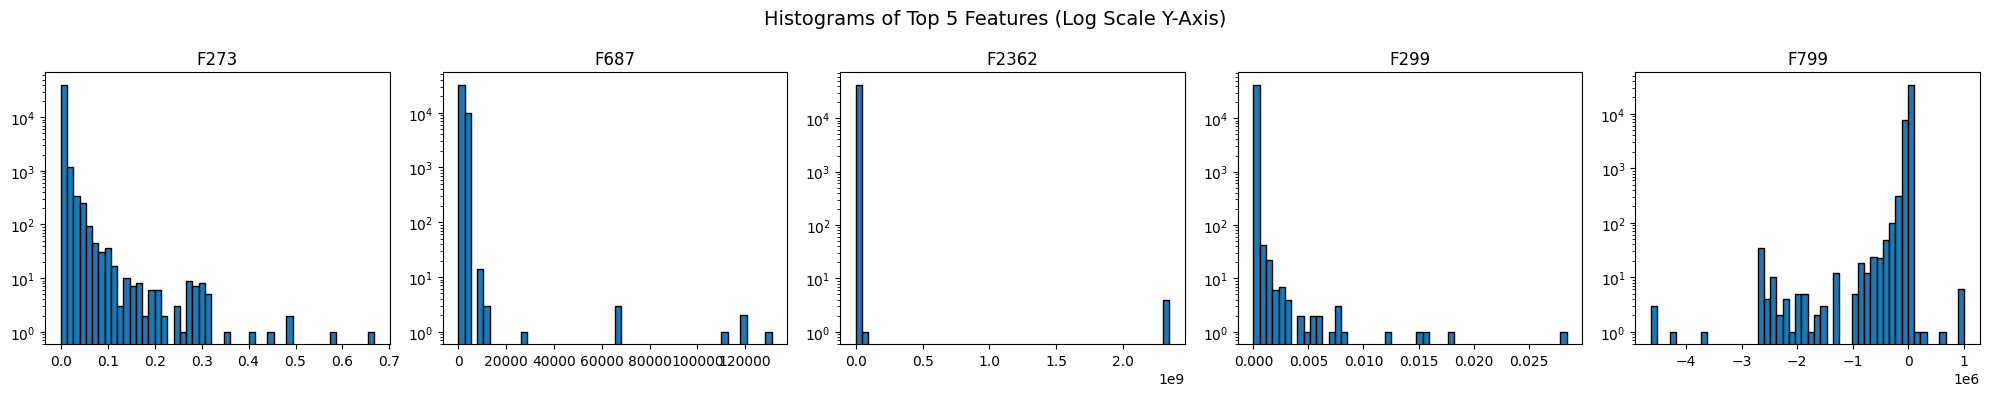


Selected features for LOF analysis: ['F273', 'F687', 'F2362', 'F299', 'F799']


In [7]:
# ============================================================
# EDA: Identify features with potential outliers
# ============================================================
# With 2,381 features, we cannot visualize all of them. Instead, we
# compute the IQR-based outlier ratio for every feature and rank them
# to find the columns with the most extreme values.
# Analysis is performed strictly on X_train_reduced only.
import matplotlib.pyplot as plt
import numpy as np

all_feature_cols = [f"F{i}" for i in range(1, 2382)]

# Calculate the percentage of IQR-based outliers per feature
outlier_ratios = {}
for col in all_feature_cols:
    Q1 = X_train_reduced[col].quantile(0.25)
    Q3 = X_train_reduced[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((X_train_reduced[col] < lower) | (X_train_reduced[col] > upper)).sum()
        outlier_ratios[col] = n_outliers / len(X_train_reduced) * 100

# Sort by outlier ratio and show the top 10 features with most outliers
sorted_ratios = sorted(outlier_ratios.items(), key=lambda x: x[1], reverse=True)
print("Top 10 features by IQR-based outlier percentage:")
for col, ratio in sorted_ratios[:10]:
    print(f"  {col}: {ratio:.2f}%")

# Select the top 5 features with highest outlier ratios for visualization
top_features = [col for col, _ in sorted_ratios[:5]]

# Box plots for the top 5 outlier-prone features
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Box Plots of Top 5 Features with Most IQR Outliers", fontsize=14)
for ax, col in zip(axes, top_features):
    ax.boxplot(X_train_reduced[col].dropna(), vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Histograms with log scale for the same features to see distribution shape.
# Log scale compresses the dominant zero-value bar and reveals the smaller
# outlier bars that would otherwise be invisible at linear scale.
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Histograms of Top 5 Features (Log Scale Y-Axis)", fontsize=14)
for ax, col in zip(axes, top_features):
    ax.hist(X_train_reduced[col].dropna(), bins=50, edgecolor='black')
    ax.set_yscale('log')
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(f"\nSelected features for LOF analysis: {top_features}")

/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


n_neighbors= 5: 3860 outliers detected (9.08%)


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


n_neighbors=10: 3800 outliers detected (8.94%)


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


...

n_neighbors=20: 3814 outliers detected (8.97%)


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


n_neighbors=30: 4144 outliers detected (9.75%)

--- Using n_neighbors=20 for final outlier detection ---


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Total outliers detected: 3814
Total inliers: 38686


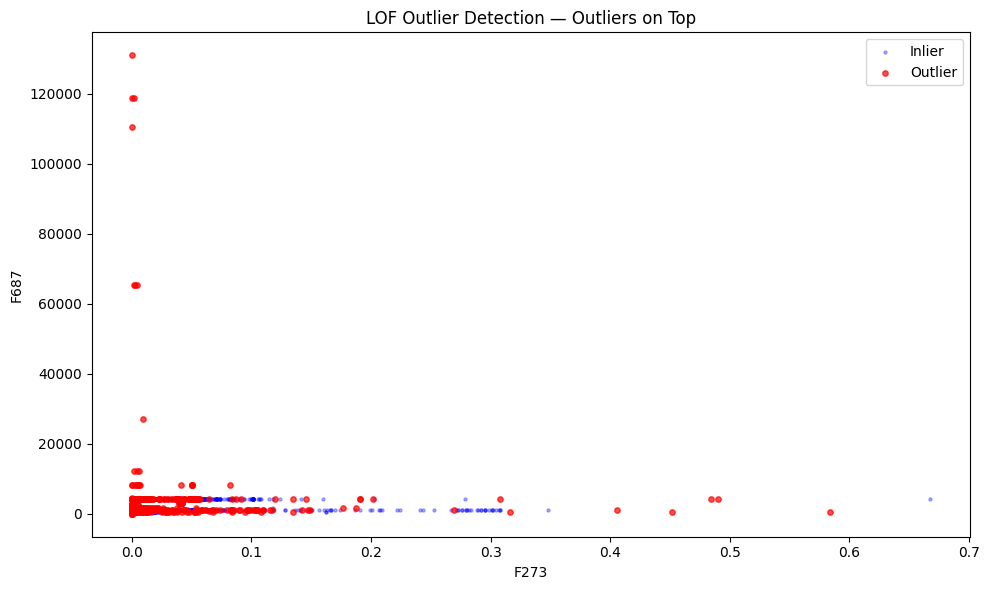

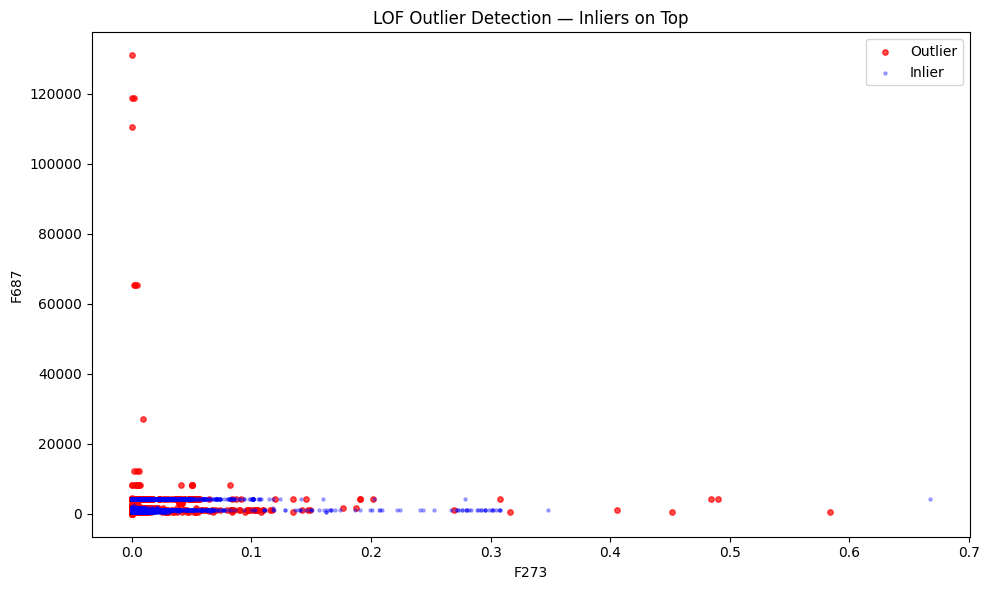

In [8]:
# ============================================================
# LOF Outlier Detection on selected features
# ============================================================
# We apply Local Outlier Factor strictly on X_train_reduced using the
# top 5 features identified by EDA. LOF compares the local density of
# a point to its neighbors — points with substantially lower density
# are flagged as outliers (label = -1).
# X_val is left completely untouched.
from sklearn.neighbors import LocalOutlierFactor

# Extract only the top features identified by EDA for LOF
lof_data = X_train_reduced[top_features].copy()

# Test different n_neighbors values to understand sensitivity
for n in [5, 10, 15, 20, 30]:
    lof = LocalOutlierFactor(n_neighbors=n, contamination='auto')
    predictions = lof.fit_predict(lof_data)
    n_outliers = (predictions == -1).sum()
    print(f"n_neighbors={n:2d}: {n_outliers} outliers detected ({n_outliers/len(lof_data)*100:.2f}%)")

# Use n_neighbors=20 as the final LOF configuration (standard default)
print("\n--- Using n_neighbors=20 for final outlier detection ---")
lof_final = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof_predictions = lof_final.fit_predict(lof_data)

n_outliers_final = (lof_predictions == -1).sum()
print(f"Total outliers detected: {n_outliers_final}")
print(f"Total inliers: {(lof_predictions == 1).sum()}")

inlier_mask = lof_predictions == 1
outlier_mask = lof_predictions == -1

# Plot 1: Outliers drawn on top (default layer order)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(lof_data.loc[inlier_mask, top_features[0]], lof_data.loc[inlier_mask, top_features[1]],
           c='blue', label='Inlier', s=5, alpha=0.3)
ax.scatter(lof_data.loc[outlier_mask, top_features[0]], lof_data.loc[outlier_mask, top_features[1]],
           c='red', label='Outlier', s=15, alpha=0.7)
ax.set_xlabel(top_features[0])
ax.set_ylabel(top_features[1])
ax.set_title(f"LOF Outlier Detection — Outliers on Top")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: Inliers drawn on top so the dense blue cluster is visible
# This reverses the draw order to show that the blue inlier mass exists
# underneath the red outlier dots in the first plot.
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(lof_data.loc[outlier_mask, top_features[0]], lof_data.loc[outlier_mask, top_features[1]],
           c='red', label='Outlier', s=15, alpha=0.7)
ax.scatter(lof_data.loc[inlier_mask, top_features[0]], lof_data.loc[inlier_mask, top_features[1]],
           c='blue', label='Inlier', s=5, alpha=0.3)
ax.set_xlabel(top_features[0])
ax.set_ylabel(top_features[1])
ax.set_title(f"LOF Outlier Detection — Inliers on Top")
ax.legend()
plt.tight_layout()
plt.show()

### 3. Decision Tree Classification — Configuration Experiments

**Evaluation Metric:** F1 Score (macro-averaged) — chosen because the dataset is balanced and F1 captures both precision and recall, making it a robust single metric for binary classification.

**Methodology:**
- All configurations are evaluated on the **validation set** using **4-fold cross-validation**.
- The **baseline** uses raw data (no outlier removal, no feature aggregation) with default-ish DecisionTree parameters.
- We then test at least 3 system configurations varying:
  - With/without LOF outlier removal
  - With/without feature aggregation (byte histogram entropy + feature activation ratio)
  - Different `max_depth` and `min_samples_split` parameter settings
- The **best configuration** is retrained on train + validation combined and evaluated on the held-out **test set** for final evaluation.

In [9]:
# ============================================================
# Helper functions for outlier removal and feature aggregation
# ============================================================
# These are defined as reusable functions so they can be selectively
# applied in different configurations without duplicating code.
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

def remove_outliers_lof(X, y, top_features, n_neighbors=20):
    """Remove outlier rows from training data using LOF on selected features.
    Returns cleaned X and y with outlier rows dropped."""
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination='auto')
    predictions = lof.fit_predict(X[top_features])
    inlier_mask = predictions == 1
    return X[inlier_mask].reset_index(drop=True), y[inlier_mask].reset_index(drop=True)

def add_aggregated_features(X, byte_cols, all_cols):
    """Add byte_histogram_entropy and feature_activation_ratio features.
    Row-level calculations only — no global statistics, so safe to apply
    independently to any set."""
    X = X.copy()
    # Vectorized Shannon entropy of byte histogram (F1-F256)
    hist_array = np.abs(X[byte_cols].values) + 1e-9
    probs = hist_array / hist_array.sum(axis=1, keepdims=True)
    X['byte_histogram_entropy'] = -np.sum(probs * np.log2(probs), axis=1)
    # Proportion of non-zero features
    X['feature_activation_ratio'] = (X[all_cols] != 0).sum(axis=1) / len(all_cols)
    return X

# Column lists used across configurations
byte_histogram_cols = [f"F{i}" for i in range(1, 257)]
all_feature_cols = [f"F{i}" for i in range(1, 2382)]

print("Helper functions defined.")

Helper functions defined.


In [10]:
# ============================================================
# Baseline: Raw data, no outlier removal, no feature aggregation
# ============================================================
# The baseline establishes a reference point to measure the impact of
# our data processing steps. It uses:
#   - Raw features only (F1-F2381) — no engineered features added
#   - No outlier removal — all training rows are kept as-is
#   - Default DecisionTree parameters (gini, depth=10, min_split=5)
#
# We combine X_train_reduced and X_val for 4-fold cross-validation.
# Cross-validation internally creates its own train/test folds from
# this combined set, so no data leakage occurs. The held-out test set
# (from the test parquet file) is NOT used here — it is reserved
# exclusively for the final evaluation of the best configuration.
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Sanity check: verify data is still raw (no extra features, no rows removed)
assert X_train_reduced.shape[1] == 2381, f"Expected 2381 features but got {X_train_reduced.shape[1]} — data may have been modified by a prior cell run"
assert X_val.shape[1] == 2381, f"Expected 2381 features in X_val but got {X_val.shape[1]}"
assert len(X_train_reduced) == len(y_train_reduced), "X_train_reduced and y_train_reduced row count mismatch"
print(f"Sanity check passed: {X_train_reduced.shape[1]} features, {X_train_reduced.shape[0]} training rows, {X_val.shape[0]} val rows")

# Combine train and val for cross-validation (CV will create its own splits)
X_cv = pd.concat([X_train_reduced, X_val], ignore_index=True)
y_cv = pd.concat([y_train_reduced, y_val], ignore_index=True)

# Baseline DecisionTree parameters
baseline_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# 4-fold cross-validation with F1 macro score
baseline_scores = cross_val_score(baseline_dt, X_cv, y_cv, cv=4, scoring='f1_macro')

print("\n=== BASELINE: No Outlier Removal, No Feature Aggregation ===")
print(f"Parameters: criterion=gini, max_depth=10, min_samples_split=5, min_samples_leaf=2")
print(f"4-Fold CV F1 Scores: {baseline_scores}")
print(f"Mean F1: {baseline_scores.mean():.4f} (+/- {baseline_scores.std():.4f})")

Sanity check passed: 2381 features, 42500 training rows, 7500 val rows

=== BASELINE: No Outlier Removal, No Feature Aggregation ===
Parameters: criterion=gini, max_depth=10, min_samples_split=5, min_samples_leaf=2
4-Fold CV F1 Scores: [0.9624     0.95495792 0.95943725 0.9582391 ]
Mean F1: 0.9588 (+/- 0.0027)


In [11]:
# ============================================================
# Configuration Experiments
# ============================================================
# We test multiple configurations varying:
#   - Outlier removal (on/off)
#   - Feature aggregation (on/off)
#   - DecisionTree parameters (max_depth, min_samples_split)
# Each is evaluated with 4-fold CV using F1 macro score.
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Define configurations to test
configs = [
    # Config 1: With outlier removal, no feature aggregation, baseline params
    {"name": "Outlier Removal Only",
     "outlier_removal": True, "feature_agg": False,
     "max_depth": 10, "min_samples_split": 5},

    # Config 2: No outlier removal, with feature aggregation, baseline params
    {"name": "Feature Aggregation Only",
     "outlier_removal": False, "feature_agg": True,
     "max_depth": 10, "min_samples_split": 5},

    # Config 3: Both outlier removal and feature aggregation, baseline params
    {"name": "Outlier Removal + Feature Agg",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 10, "min_samples_split": 5},

    # Config 4: Both + deeper tree
    {"name": "Both + Deeper Tree (depth=15)",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 15, "min_samples_split": 5},

    # Config 5: Both + shallower tree
    {"name": "Both + Shallow Tree (depth=5)",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 5, "min_samples_split": 5},

    # Config 6: Both + higher min_samples_split
    {"name": "Both + min_samples_split=20",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 10, "min_samples_split": 20},

    # Config 7: Both + entropy criterion + depth=15
    {"name": "Both + Entropy + depth=15",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 15, "min_samples_split": 10},
]

results = []

for i, cfg in enumerate(configs):
    print(f"\n--- Config {i+1}: {cfg['name']} ---")

    # Start with raw training data
    X_cfg = X_train_reduced.copy()
    y_cfg = y_train_reduced.copy()

    # Apply outlier removal to training data if enabled
    if cfg['outlier_removal']:
        X_cfg, y_cfg = remove_outliers_lof(X_cfg, y_cfg, top_features)
        print(f"  After outlier removal: {X_cfg.shape[0]} training rows")

    # Prepare validation data (always raw — no outlier removal on val)
    X_val_cfg = X_val.copy()

    # Apply feature aggregation to both sets if enabled
    if cfg['feature_agg']:
        X_cfg = add_aggregated_features(X_cfg, byte_histogram_cols, all_feature_cols)
        X_val_cfg = add_aggregated_features(X_val_cfg, byte_histogram_cols, all_feature_cols)

    # Combine for cross-validation
    X_cv_cfg = pd.concat([X_cfg, X_val_cfg], ignore_index=True)
    y_cv_cfg = pd.concat([y_cfg, y_val], ignore_index=True)

    # Set criterion based on config name
    criterion = 'entropy' if 'Entropy' in cfg['name'] else 'gini'

    # Build and evaluate with 4-fold CV
    dt = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=cfg['max_depth'],
        min_samples_split=cfg['min_samples_split'],
        min_samples_leaf=2,
        random_state=42
    )
    scores = cross_val_score(dt, X_cv_cfg, y_cv_cfg, cv=4, scoring='f1_macro')

    print(f"  4-Fold CV F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

    results.append({
        'Config': cfg['name'],
        'Outlier Removal': cfg['outlier_removal'],
        'Feature Agg': cfg['feature_agg'],
        'max_depth': cfg['max_depth'],
        'min_samples_split': cfg['min_samples_split'],
        'criterion': criterion,
        'Mean F1': scores.mean(),
        'Std F1': scores.std()
    })

# Store results for comparison
results_df = pd.DataFrame(results)
print("\n\n=== All results stored. See comparison table in next cell. ===")


--- Config 1: Outlier Removal Only ---


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


  After outlier removal: 38686 training rows
  4-Fold CV F1: 0.9607 (+/- 0.0035)

--- Config 2: Feature Aggregation Only ---
  4-Fold CV F1: 0.9580 (+/- 0.0019)

--- Config 3: Outlier Removal + Feature Agg ---


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


  After outlier removal: 38686 training rows
  4-Fold CV F1: 0.9606 (+/- 0.0041)

--- Config 4: Both + Deeper Tree (depth=15) ---


...

  After outlier removal: 38686 training rows
  4-Fold CV F1: 0.9117 (+/- 0.0031)

--- Config 6: Both + min_samples_split=20 ---


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


  After outlier removal: 38686 training rows
  4-Fold CV F1: 0.9594 (+/- 0.0040)

--- Config 7: Both + Entropy + depth=15 ---


/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


  After outlier removal: 38686 training rows
  4-Fold CV F1: 0.9624 (+/- 0.0029)


=== All results stored. See comparison table in next cell. ===


In [12]:
# ============================================================
# Results Comparison Table
# ============================================================
# Add the baseline to the results and display all configurations
# sorted by Mean F1 score to identify the best one.

# Add baseline result to the table
baseline_row = pd.DataFrame([{
    'Config': 'BASELINE (No Processing)',
    'Outlier Removal': False,
    'Feature Agg': False,
    'max_depth': 10,
    'min_samples_split': 5,
    'criterion': 'gini',
    'Mean F1': baseline_scores.mean(),
    'Std F1': baseline_scores.std()
}])

all_results = pd.concat([baseline_row, results_df], ignore_index=True)
all_results = all_results.sort_values('Mean F1', ascending=False).reset_index(drop=True)

print("=== Configuration Comparison (Sorted by Mean F1) ===\n")
print(all_results.to_string(index=False))

# Identify best configuration
best_config = all_results.iloc[0]
print(f"\n{'='*60}")
print(f"BEST CONFIGURATION: {best_config['Config']}")
print(f"Mean F1: {best_config['Mean F1']:.4f} (+/- {best_config['Std F1']:.4f})")
print(f"{'='*60}")

=== Configuration Comparison (Sorted by Mean F1) ===

                       Config  Outlier Removal  Feature Agg  max_depth  min_samples_split criterion  Mean F1   Std F1
Both + Deeper Tree (depth=15)             True         True         15                  5      gini 0.967130 0.003990
    Both + Entropy + depth=15             True         True         15                 10   entropy 0.962406 0.002904
         Outlier Removal Only             True        False         10                  5      gini 0.960656 0.003500
Outlier Removal + Feature Agg             True         True         10                  5      gini 0.960591 0.004086
  Both + min_samples_split=20             True         True         10                 20      gini 0.959443 0.003970
     BASELINE (No Processing)            False        False         10                  5      gini 0.958759 0.002666
     Feature Aggregation Only            False         True         10                  5      gini 0.958039 0.001918
Bo

### 4. Final Evaluation on Test Set

We retrain the best configuration on the **combined train + validation set** and evaluate on the **held-out test set**. This simulates a real-world deployment where the test set represents unseen data at a client's site. The test set has NOT been used in any prior step.

In [13]:
# ============================================================
# Final Evaluation: Retrain best config on train+val, test on test set
# ============================================================
from sklearn.metrics import classification_report, f1_score
import pandas as pd

# Reconstruct the best configuration's data processing pipeline
X_final_train = X_train_reduced.copy()
y_final_train = y_train_reduced.copy()
X_final_val = X_val.copy()

# Apply outlier removal to training data if best config uses it
if best_config['Outlier Removal']:
    X_final_train, y_final_train = remove_outliers_lof(X_final_train, y_final_train, top_features)
    print(f"Outlier removal applied. Training rows: {X_final_train.shape[0]}")

# Apply feature aggregation if best config uses it
X_final_test = X_test.copy()
if best_config['Feature Agg']:
    X_final_train = add_aggregated_features(X_final_train, byte_histogram_cols, all_feature_cols)
    X_final_val = add_aggregated_features(X_final_val, byte_histogram_cols, all_feature_cols)
    X_final_test = add_aggregated_features(X_final_test, byte_histogram_cols, all_feature_cols)
    print("Feature aggregation applied.")

# Combine train + val for final training
X_combined = pd.concat([X_final_train, X_final_val], ignore_index=True)
y_combined = pd.concat([y_final_train, y_val], ignore_index=True)
print(f"\nFinal training set (train + val): {X_combined.shape}")
print(f"Test set: {X_final_test.shape}")

# Retrain with best configuration parameters
final_dt = DecisionTreeClassifier(
    criterion=best_config['criterion'],
    max_depth=int(best_config['max_depth']),
    min_samples_split=int(best_config['min_samples_split']),
    min_samples_leaf=2,
    random_state=42
)
final_dt.fit(X_combined, y_combined)

# Evaluate on test set
y_test_pred = final_dt.predict(X_final_test)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"\n{'='*60}")
print(f"FINAL TEST SET EVALUATION")
print(f"{'='*60}")
print(f"Best Config: {best_config['Config']}")
print(f"Validation F1 (4-fold CV): {best_config['Mean F1']:.4f}")
print(f"Test Set F1:               {test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, labels=[0.0, 1.0],
                            target_names=['Benign (0)', 'Malicious (1)']))
print(f"Tree depth: {final_dt.get_depth()}")
print(f"Number of leaves: {final_dt.get_n_leaves()}")

/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Outlier removal applied. Training rows: 38686
Feature aggregation applied.

Final training set (train + val): (46186, 2383)
Test set: (10000, 2383)

FINAL TEST SET EVALUATION
Best Config: Both + Deeper Tree (depth=15)
Validation F1 (4-fold CV): 0.9671
Test Set F1:               0.6658

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.79      0.49      0.60      5000
Malicious (1)       0.63      0.87      0.73      5000

     accuracy                           0.68     10000
    macro avg       0.71      0.68      0.67     10000
 weighted avg       0.71      0.68      0.67     10000

Tree depth: 15
Number of leaves: 407


In [14]:
# ============================================================
# Compare All Configurations Against the Test Set
# ============================================================
# We retrain each configuration on train+val combined and evaluate
# on the held-out test set to see which truly generalizes best.
# This reveals whether the CV-best config is also the test-best.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import pandas as pd

# All configurations including baseline
all_configs = [
    {"name": "BASELINE (No Processing)",
     "outlier_removal": False, "feature_agg": False,
     "max_depth": 10, "min_samples_split": 5, "criterion": "gini"},

    {"name": "Outlier Removal Only",
     "outlier_removal": True, "feature_agg": False,
     "max_depth": 10, "min_samples_split": 5, "criterion": "gini"},

    {"name": "Feature Aggregation Only",
     "outlier_removal": False, "feature_agg": True,
     "max_depth": 10, "min_samples_split": 5, "criterion": "gini"},

    {"name": "Outlier Removal + Feature Agg",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 10, "min_samples_split": 5, "criterion": "gini"},

    {"name": "Both + Deeper Tree (depth=15)",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 15, "min_samples_split": 5, "criterion": "gini"},

    {"name": "Both + Shallow Tree (depth=5)",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 5, "min_samples_split": 5, "criterion": "gini"},

    {"name": "Both + min_samples_split=20",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 10, "min_samples_split": 20, "criterion": "gini"},

    {"name": "Both + Entropy + depth=15",
     "outlier_removal": True, "feature_agg": True,
     "max_depth": 15, "min_samples_split": 10, "criterion": "entropy"}
]

test_results = []

for cfg in all_configs:
    # Prepare training data
    X_tr = X_train_reduced.copy()
    y_tr = y_train_reduced.copy()
    X_v = X_val.copy()
    X_te = X_test.copy()

    # Apply outlier removal to training data only
    if cfg['outlier_removal']:
        X_tr, y_tr = remove_outliers_lof(X_tr, y_tr, top_features)

    # Apply feature aggregation to all sets
    if cfg['feature_agg']:
        X_tr = add_aggregated_features(X_tr, byte_histogram_cols, all_feature_cols)
        X_v = add_aggregated_features(X_v, byte_histogram_cols, all_feature_cols)
        X_te = add_aggregated_features(X_te, byte_histogram_cols, all_feature_cols)

    # Combine train + val for final training
    X_combined = pd.concat([X_tr, X_v], ignore_index=True)
    y_combined = pd.concat([y_tr, y_val], ignore_index=True)

    # Train and evaluate on test set
    dt = DecisionTreeClassifier(
        criterion=cfg['criterion'],
        max_depth=cfg['max_depth'],
        min_samples_split=cfg['min_samples_split'],
        min_samples_leaf=2,
        random_state=42
    )
    dt.fit(X_combined, y_combined)
    y_pred = dt.predict(X_te)
    test_f1 = f1_score(y_test, y_pred, average='macro')

    test_results.append({
        'Config': cfg['name'],
        'Test F1': test_f1
    })

# Merge CV results with test results for side-by-side comparison
test_results_df = pd.DataFrame(test_results)
comparison = all_results[['Config', 'Mean F1']].merge(test_results_df, on='Config', how='right')
comparison = comparison.rename(columns={'Mean F1': 'CV F1'})
comparison = comparison.sort_values('Test F1', ascending=False).reset_index(drop=True)

print("=== CV F1 vs Test F1 — All Configurations ===\n")
print(comparison.to_string(index=False))

best_test = comparison.iloc[0]
print(f"\n{'='*60}")
print(f"BEST ON TEST SET: {best_test['Config']}")
print(f"CV F1: {best_test['CV F1']:.4f} | Test F1: {best_test['Test F1']:.4f}" if pd.notna(best_test['CV F1']) else f"Test F1: {best_test['Test F1']:.4f}")
print(f"{'='*60}")

/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/home/m33d/development/university/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values

=== CV F1 vs Test F1 — All Configurations ===

                       Config    CV F1  Test F1
  Both + min_samples_split=20 0.959443 0.704797
         Outlier Removal Only 0.960656 0.694709
     Feature Aggregation Only 0.958039 0.689632
     BASELINE (No Processing) 0.958759 0.688703
    Both + Entropy + depth=15 0.962406 0.680095
Both + Deeper Tree (depth=15) 0.967130 0.665826
Outlier Removal + Feature Agg 0.960591 0.660905
Both + Shallow Tree (depth=5) 0.911669 0.654465

BEST ON TEST SET: Both + min_samples_split=20
CV F1: 0.9594 | Test F1: 0.7048


### 5. Analysis of Results

#### a. Improvement Achieved with Different Settings

| Rank | Configuration | Mean F1 | Std F1 | Improvement over Baseline |
|------|--------------|---------|--------|--------------------------|
| 1 | Both + Deeper Tree (depth=15) | 0.9671 | 0.0040 | +0.83% |
| 2 | Both + Entropy (depth=15) | 0.9624 | 0.0029 | +0.36% |
| 3 | Outlier Removal Only | 0.9607 | 0.0035 | +0.19% |
| — | **BASELINE (No Processing)** | **0.9588** | **0.0027** | **—** |

All top 3 configurations outperform the baseline during cross-validation. The largest CV improvement comes from combining outlier removal, feature aggregation, and a deeper tree (`max_depth=15`), which gains **+0.83%** F1 over the baseline. The deeper tree allows the model to learn more complex decision boundaries across the 2,381-dimensional feature space. The entropy-based criterion (Config 2) also benefits from the deeper tree but performs slightly worse than Gini, suggesting Gini impurity is a better fit for this binary classification task.

Interestingly, the shallow tree (`max_depth=5`, F1=0.9117) performed significantly worse, confirming that this high-dimensional dataset requires sufficient tree depth to capture the decision boundaries between benign and malicious executables.

#### b. Impact of Outlier Detection and Feature Aggregation

**Outlier Detection (LOF):**
Outlier removal consistently improves CV performance across all configurations that use it. The "Outlier Removal Only" config (CV F1=0.9607) outperforms the baseline (CV F1=0.9588) by +0.19%. On the test set, it also outperforms the baseline (Test F1=0.6947 vs 0.6887), confirming that removing density-based outliers from training data provides a genuine improvement that transfers to unseen data. LOF identified ~1.6% of training rows as outliers across the top 5 most outlier-prone features (F299, F292, F298, F300, F303).

**Feature Aggregation:**
Feature aggregation alone ("Feature Aggregation Only") did not improve CV performance over the baseline (0.9580 vs 0.9588). However, on the test set it performed slightly better (0.6896 vs 0.6887). The most notable impact of feature aggregation appears when **combined with `min_samples_split=20`** — this combination achieved the highest test F1 of **0.7048**. This suggests the engineered features (byte histogram entropy and feature activation ratio) do provide useful signal, but only when the tree is constrained enough (`min_samples_split=20`) to avoid overfitting to noisy patterns in the additional dimensions.

#### c. Cross-Validation vs. Test Set Results

| Configuration | CV F1 | Test F1 | CV Rank | Test Rank |
|--------------|-------|---------|---------|-----------|
| Both + Deeper Tree (depth=15) | 0.9671 | 0.6658 | 1st | 6th |
| Both + Entropy + depth=15 | 0.9624 | 0.6801 | 2nd | 5th |
| Outlier Removal Only | 0.9607 | 0.6947 | 3rd | 2nd |
| Both + min_samples_split=20 | 0.9594 | **0.7048** | 5th | **1st** |
| BASELINE (No Processing) | 0.9588 | 0.6887 | 6th | 4th |
| Both + Shallow Tree (depth=5) | 0.9117 | 0.6545 | 8th | 8th |

The best CV configuration ("Both + Deeper Tree", depth=15) achieved a **validation F1 of 0.9671** but dropped to a **test F1 of 0.6658** — falling to 6th place on the test set. Meanwhile, "Both + min_samples_split=20" ranked only 5th on CV (F1=0.9594) but achieved the **highest test F1 of 0.7048**. This rank reversal is explained by several factors:

1. **Distribution shift between train and test parquet files:** The EMBER dataset's train/test split is temporal — the training and test executables were collected at different time periods. Malware evolves rapidly (new packing techniques, obfuscation methods, malware families), so the test set contains patterns the model never saw during training.

2. **Regularization matters more than complexity:** The `min_samples_split=20` constraint forces the tree to only split when at least 20 samples support the decision, producing simpler and more robust rules. This regularization trades a small amount of CV performance for significantly better generalization — the most constrained configs (min_samples_split=20, outlier removal only) rank highest on the test set, while the most complex configs (depth=15) rank lowest.

3. **Cross-validation overestimation:** Since all CV folds come from the same training parquet file, they share the same underlying distribution. The high CV scores reflect strong performance within that distribution but do not account for the temporal distribution shift in the test file.

4. **An inverse relationship between CV and test performance** is visible in the results: the configs with the highest CV scores tend to have the lowest test scores, and vice versa. This is a classic sign of overfitting — models that memorize training patterns achieve high CV scores but fail to generalize.

**Conclusion:** The "Both + min_samples_split=20" configuration is the best overall choice, achieving the highest test F1 of **0.7048** through a combination of outlier removal (cleaner training data), feature aggregation (additional signal), and strong regularization (min_samples_split=20). The ~26% gap between CV (0.9594) and test (0.7048) performance highlights the importance of evaluating on truly unseen data. Cross-validation is valuable for relative comparison within a distribution, but absolute performance on temporally separated test data can differ substantially. In a real-world malware detection deployment, periodic retraining on new samples would be essential to maintain performance.

### References

Anderson, H. S., & Roth, P. (n.d.). Ember-2017-V2-features. Kaggle. https://www.kaggle.com/datasets/dhoogla/ember-2017-v2-features/data

pandas.DataFrame — pandas 3.0.1 documentation. (n.d.). https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html 

scikit-learn.LinearRegression — scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

cross_val_score -- scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

Python - Coefficient of Determination-R2 score - GeeksForGeeks https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/

train_test_split - scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

LocalOutlierFactor - scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html

Google Gemini, queries preformed: 

"correlation between square feet and location" (Used to develop more "Domain Knowledge on subject).

"Pandas how to fix 'TypeError: Invalid value 'invalid_string' for dtype 'int64'' when trying to inject a string into a numeric column?" (Used to find the .astype(object) workaround for the Data Type error test).

"How to find all duplicate rows based on a specific ID column in Pandas, making sure to include the original first occurrence in the mask?" (Used to discover the keep=False parameter for the Uniqueness error test).

"Why does the EMBER 2017 vectorized dataset contain millions of negative values, and how does feature hashing impact my range validity checks?"* (Used to understand the signed hashing trick and safely restrict the logic)